## 04: Evaluation and Comparison

Loads the saved GIN and GAT checkpoints and evaluates both on the official ogbg-molhiv test split using OGB's Evaluator (ROC-AUC). Plots ROC and precision-recall curves for both models side by side, and closes with a comparison table against published entries on OGB's public leaderboard, with a note on what those top entries do differently from this project.

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
# BASE_DIR = "/content/drive/MyDrive/molhiv-gnn"

# !pip install torch-geometric ogb rdkit

BASE_DIR = ".."

In [2]:
import pandas as pd
import os
import json
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch_geometric
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, GATConv, global_mean_pool
from ogb.graphproppred import PygGraphPropPredDataset, Evaluator
from ogb.graphproppred.mol_encoder import AtomEncoder

torch.serialization.add_safe_globals([
    torch_geometric.data.data.DataEdgeAttr,
    torch_geometric.data.data.DataTensorAttr,
    torch_geometric.data.storage.GlobalStorage,
])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
dataset = PygGraphPropPredDataset(name="ogbg-molhiv", root=f"{BASE_DIR}/dataset")
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name="ogbg-molhiv")
test_loader = DataLoader(dataset[split_idx["test"]], batch_size=256, shuffle=False)

with open(f"{BASE_DIR}/outputs/results.json") as f:
    results = json.load(f)

results

{'gin': {'config': {'hidden_dim': 256, 'num_layers': 5, 'dropout': 0.2},
  'val_rocauc': 0.8081735008818343,
  'test_rocauc': 0.7597539543057998},
 'gat': {'config': {'hidden_dim': 64,
   'num_layers': 3,
   'dropout': 0.2,
   'heads': 4},
  'val_rocauc': 0.7993735302763081,
  'test_rocauc': 0.7402846713918769}}

In [4]:
class GIN(nn.Module):
    def __init__(self, hidden_dim, num_layers, dropout):
        super().__init__()
        self.atom_encoder = AtomEncoder(hidden_dim)
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for _ in range(num_layers):
            mlp = nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
            )
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.dropout = dropout
        self.out = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        h = self.atom_encoder(x)
        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, edge_index)
            h = bn(h)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
        h = global_mean_pool(h, batch)
        return self.out(h).squeeze(-1)


class GAT(nn.Module):
    def __init__(self, hidden_dim, num_layers, dropout, heads):
        super().__init__()
        self.atom_encoder = AtomEncoder(hidden_dim)
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        in_dim = hidden_dim
        for i in range(num_layers):
            is_last = i == num_layers - 1
            concat = not is_last
            conv = GATConv(in_dim, hidden_dim, heads=heads, concat=concat, dropout=dropout)
            self.convs.append(conv)
            in_dim = hidden_dim * heads if concat else hidden_dim
            self.bns.append(nn.BatchNorm1d(in_dim))
        self.dropout = dropout
        self.out = nn.Linear(in_dim, 1)

    def forward(self, x, edge_index, batch):
        h = self.atom_encoder(x)
        for conv, bn in zip(self.convs, self.bns):
            h = conv(h, edge_index)
            h = bn(h)
            h = F.elu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
        h = global_mean_pool(h, batch)
        return self.out(h).squeeze(-1)

In [5]:
gin_model = GIN(**results["gin"]["config"]).to(device)
gin_model.load_state_dict(torch.load(f"{BASE_DIR}/models/gin_best.pt", map_location=device))
gin_model.eval()

gat_model = GAT(**results["gat"]["config"]).to(device)
gat_model.load_state_dict(torch.load(f"{BASE_DIR}/models/gat_best.pt", map_location=device))
gat_model.eval()


@torch.no_grad()
def get_probs(model, loader):
    y_true, y_pred = [], []
    for batch in loader:
        batch = batch.to(device)
        out = model(batch.x, batch.edge_index, batch.batch)
        y_true.append(batch.y.view(-1).cpu())
        y_pred.append(torch.sigmoid(out).view(-1).cpu())
    return torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()


gin_y_true, gin_y_pred = get_probs(gin_model, test_loader)
gat_y_true, gat_y_pred = get_probs(gat_model, test_loader)

gin_test_auc = evaluator.eval({"y_true": gin_y_true.reshape(-1, 1), "y_pred": gin_y_pred.reshape(-1, 1)})["rocauc"]
gat_test_auc = evaluator.eval({"y_true": gat_y_true.reshape(-1, 1), "y_pred": gat_y_pred.reshape(-1, 1)})["rocauc"]

print(f"{'Model':<6}{'Test ROC-AUC':>14}")
print(f"{'GIN':<6}{gin_test_auc:>14.4f}")
print(f"{'GAT':<6}{gat_test_auc:>14.4f}")

Model   Test ROC-AUC
GIN           0.7598
GAT           0.7403


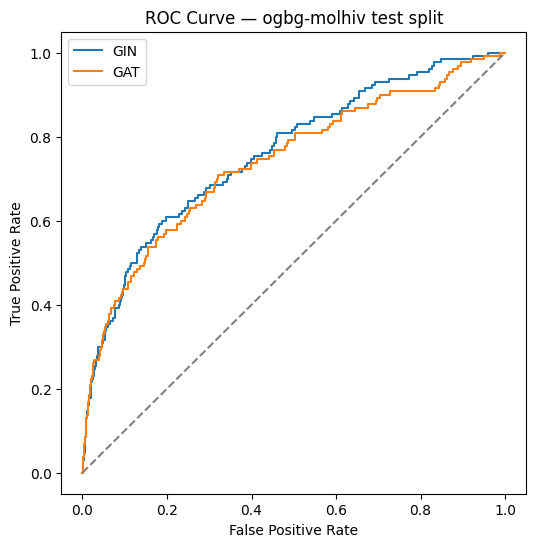

In [6]:
os.makedirs(f"{BASE_DIR}/outputs/figures", exist_ok=True)

fig, ax = plt.subplots(figsize=(6, 6))
for name, y_true, y_pred in [("GIN", gin_y_true, gin_y_pred), ("GAT", gat_y_true, gat_y_pred)]:
    fpr, tpr, _ = roc_curve(y_true, y_pred)
    ax.plot(fpr, tpr, label=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — ogbg-molhiv test split")
ax.legend()
fig.savefig(f"{BASE_DIR}/outputs/figures/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

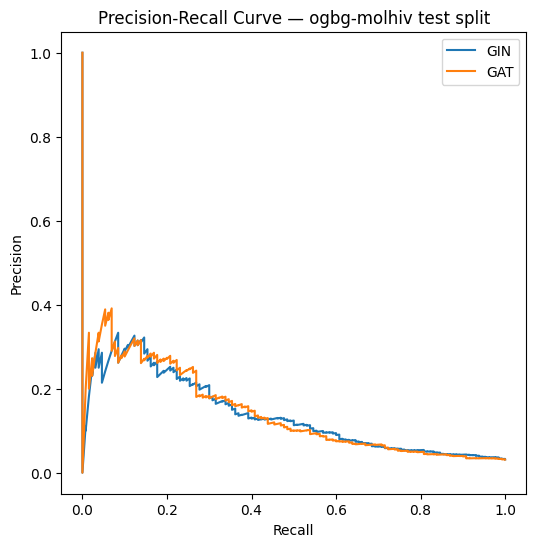

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, y_true, y_pred in [("GIN", gin_y_true, gin_y_pred), ("GAT", gat_y_true, gat_y_pred)]:
    precision, recall, _ = precision_recall_curve(y_true, y_pred)
    ax.plot(recall, precision, label=name)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve — ogbg-molhiv test split")
ax.legend()
fig.savefig(f"{BASE_DIR}/outputs/figures/pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
leaderboard_snapshot = [
    ("Multi-RF Fusion + Multi-GNN (rank 1)", 0.8476, 0.0002),
    ("HyperFusion (rank 2)", 0.8475, 0.0003),
    ("PAS+FPs (rank 3)", 0.8420, 0.0015),
    ("GIN+virtual node (OGB team baseline)", 0.7707, 0.0149),
    ("GCN (OGB team baseline)", 0.7606, 0.0097),
    ("GIN (OGB team baseline, no virtual node)", 0.7558, 0.0140),
    ("This project — GIN", gin_test_auc, None),
    ("This project — GAT", gat_test_auc, None),
]

print(f"{'Entry':<45}{'Test ROC-AUC':>14}")
for name, auc, std in leaderboard_snapshot:
    auc_str = f"{auc:.4f} ± {std:.4f}" if std is not None else f"{auc:.4f}"
    print(f"{name:<45}{auc_str:>18}")

Entry                                          Test ROC-AUC
Multi-RF Fusion + Multi-GNN (rank 1)            0.8476 ± 0.0002
HyperFusion (rank 2)                            0.8475 ± 0.0003
PAS+FPs (rank 3)                                0.8420 ± 0.0015
GIN+virtual node (OGB team baseline)            0.7707 ± 0.0149
GCN (OGB team baseline)                         0.7606 ± 0.0097
GIN (OGB team baseline, no virtual node)        0.7558 ± 0.0140
This project — GIN                                       0.7598
This project — GAT                                       0.7403
